In [5]:
# ------------------------------------------------------------
# STEP 1: LOAD DATA (PRE-CLEANED WITH CORRIDOR, CLUSTER, ETC.)
# ------------------------------------------------------------

import pandas as pd
import numpy as np

path = "gs://agntworks-data-dev/sandbox/experiments/xodm_quotes_clean_corridor_v1.csv"

df = pd.read_csv(path)

print("Shape:", df.shape)
df.head()

Shape: (18444, 10)


,Quote_ID,Date_Quoted,Trip_Departure_Date,dep_icao,arr_icao,dep_cluster,arr_cluster,corridor,Quote_Total_Cost,Trip_Status
0,423681001GEOA08,2015-12-31,2016-01-04,KMIA,KAUS,MIAMI_CLUSTER,HOUSTON_CLUSTER,MIAMI_CLUSTER→HOUSTON_CLUSTER,26117.13,NaN
1,423681017GEOA08,2015-12-31,2016-01-01,KTEB,TJSJ,NEW_YORK_CLUSTER,SAN_JUAN_CLUSTER,NEW_YORK_CLUSTER→SAN_JUAN_CLUSTER,0.00,Cancelled
2,423681029GEOA08,2015-12-31,2016-01-02,KFMY,KCRQ,MIAMI_CLUSTER,SAN_DIEGO_CLUSTER,MIAMI_CLUSTER→SAN_DIEGO_CLUSTER,77311.85,NaN
3,423681030SERD08,2015-12-31,2016-01-08,KFOK,KPBI,NEW_YORK_CLUSTER,MIAMI_CLUSTER,NEW_YORK_CLUSTER→MIAMI_CLUSTER,13387.50,Completed
4,423681055GEOA08,2015-12-31,2016-01-02,KMMU,KSFO,NEW_YORK_CLUSTER,SAN_FRANCISCO_CLUSTER,NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,45000.00,NaN


In [6]:
# ------------------------------------------------------------
# STEP 2: VERIFY KEY FIELDS EXIST
# ------------------------------------------------------------

required_cols = ["Quote_ID", "Trip_Status", "corridor", "Quote_Total_Cost"]

for col in required_cols:
    print(col, "→", "OK" if col in df.columns else "MISSING")

Quote_ID → OK
Trip_Status → OK
corridor → OK
Quote_Total_Cost → OK


In [7]:
# ------------------------------------------------------------
# STEP 2.5: INSPECT TRIP_STATUS VALUES
# ------------------------------------------------------------

print("Unique Trip_Status values:")
print(df["Trip_Status"].dropna().unique())

print("\nCounts:")
print(df["Trip_Status"].value_counts(dropna=False))

Unique Trip_Status values:
['Cancelled' 'Completed' 'Scheduled' 'Cancelled Reserved']

Counts:
Trip_Status
NaN                   13233
Completed              4467
Cancelled               454
Scheduled               289
Cancelled Reserved        1
Name: count, dtype: int64


In [8]:
# ------------------------------------------------------------
# STEP 3: DEFINE CONVERSION FLAG
# ------------------------------------------------------------

# LOGIC:
# Completed → real flown trip → TRUE conversion
# Everything else (NULL, Cancelled, Scheduled) → NOT converted (for now)

df["converted"] = np.where(df["Trip_Status"] == "Completed", 1, 0)

# sanity check
print("Overall conversion rate:", df["converted"].mean())

Overall conversion rate: 0.2421925829538061


In [9]:
# ------------------------------------------------------------
# STEP 4: HIGH LEVEL SANITY CHECK
# ------------------------------------------------------------

total_quotes = len(df)
total_converted = df["converted"].sum()

print("Total quotes:", total_quotes)
print("Total converted (flown):", total_converted)
print("Conversion rate:", total_converted / total_quotes)

Total quotes: 18444
Total converted (flown): 4467
Conversion rate: 0.2421925829538061


In [10]:
# ------------------------------------------------------------
# STEP 5: CREATE BOOKED FLAG (FOR LATER USE)
# ------------------------------------------------------------

# This includes scheduled (booked but not flown)
df["booked_flag"] = np.where(
    df["Trip_Status"].isin(["Completed", "Scheduled"]),
    1,
    0
)

print("Booked rate (looser):", df["booked_flag"].mean())

Booked rate (looser): 0.2578616352201258


In [11]:
# ------------------------------------------------------------
# STEP 6: MEASURE CONVERSION BY CORRIDOR
# ------------------------------------------------------------

conv_corridor = (
    df.groupby("corridor")
      .agg(
          quotes=("Quote_ID", "count"),        # total opportunities
          bookings=("converted", "sum"),       # successful outcomes
          conversion_rate=("converted", "mean")
      )
      .reset_index()
)

conv_corridor.head()

,corridor,quotes,bookings,conversion_rate
0,ASPEN_CLUSTER→ATLANTA_CLUSTER,11,1,0.090909
1,ASPEN_CLUSTER→BOSTON_CLUSTER,18,4,0.222222
2,ASPEN_CLUSTER→CABO_CLUSTER,1,0,0.000000
3,ASPEN_CLUSTER→CHICAGO_CLUSTER,30,1,0.033333
4,ASPEN_CLUSTER→DALLAS_CLUSTER,15,1,0.066667


In [12]:
# ------------------------------------------------------------
# STEP 7: FILTER OUT NOISY CORRIDORS
# ------------------------------------------------------------

MIN_QUOTES = 50

conv_corridor = conv_corridor[
    conv_corridor["quotes"] >= MIN_QUOTES
]

print("Remaining corridors:", len(conv_corridor))

Remaining corridors: 98


In [13]:
# ------------------------------------------------------------
# STEP 8: TOP PERFORMERS
# ------------------------------------------------------------

conv_corridor.sort_values(
    by="conversion_rate",
    ascending=False
).head(20)

,corridor,quotes,bookings,conversion_rate
296,MIAMI_CLUSTER→ORLANDO_CLUSTER,58,31,0.534483
455,SAN_FRANCISCO_CLUSTER→SAN_DIEGO_CLUSTER,52,26,0.500000
230,LAS_VEGAS_CLUSTER→LOS_ANGELES_CLUSTER,53,26,0.490566
269,LOS_ANGELES_CLUSTER→PHOENIX_CLUSTER,63,30,0.476190
526,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,83,38,0.457831
446,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,284,120,0.422535
57,BOSTON_CLUSTER→NEW_YORK_CLUSTER,180,72,0.400000
488,SEATTLE_CLUSTER→NEW_YORK_CLUSTER,52,19,0.365385
187,HOUSTON_CLUSTER→MIAMI_CLUSTER,59,21,0.355932
282,MIAMI_CLUSTER→BOSTON_CLUSTER,181,63,0.348066


In [14]:
# ------------------------------------------------------------
# STEP 9: LOW PERFORMERS
# ------------------------------------------------------------

conv_corridor.sort_values(
    by="conversion_rate",
    ascending=True
).head(20)

,corridor,quotes,bookings,conversion_rate
259,LOS_ANGELES_CLUSTER→HONOLULU_CLUSTER,50,0,0.000000
31,ATLANTA_CLUSTER→LOS_ANGELES_CLUSTER,91,8,0.087912
302,MIAMI_CLUSTER→SAN_JUAN_CLUSTER,68,6,0.088235
105,CHICAGO_CLUSTER→LOS_ANGELES_CLUSTER,138,14,0.101449
54,BOSTON_CLUSTER→LOS_ANGELES_CLUSTER,88,9,0.102273
264,LOS_ANGELES_CLUSTER→MIAMI_CLUSTER,183,19,0.103825
253,LOS_ANGELES_CLUSTER→BOSTON_CLUSTER,120,14,0.116667
252,LOS_ANGELES_CLUSTER→ATLANTA_CLUSTER,116,14,0.120690
233,LAS_VEGAS_CLUSTER→NEW_YORK_CLUSTER,71,9,0.126761
51,BOSTON_CLUSTER→JACKSON_HOLE_CLUSTER,65,9,0.138462


In [15]:
# ------------------------------------------------------------
# STEP 10: UNDERSTAND SPREAD
# ------------------------------------------------------------

conv_corridor["conversion_rate"].describe()

count    98.000000
mean      0.240339
std       0.093992
min       0.000000
25%       0.179436
50%       0.228054
75%       0.289221
max       0.534483
Name: conversion_rate, dtype: float64

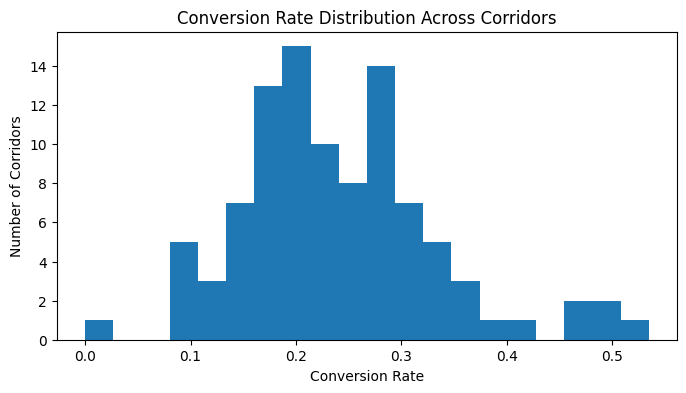

In [16]:
# ------------------------------------------------------------
# STEP 11: HISTOGRAM OF CONVERSION
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(conv_corridor["conversion_rate"], bins=20)
plt.title("Conversion Rate Distribution Across Corridors")
plt.xlabel("Conversion Rate")
plt.ylabel("Number of Corridors")
plt.show()

In [17]:
# ------------------------------------------------------------
# STEP 12: CREATE PRICE BUCKETS
# ------------------------------------------------------------

# We use quantiles so buckets are balanced
df["price_bucket"] = pd.qcut(
    df["Quote_Total_Cost"],
    q=5,                      # 5 buckets (quintiles)
    duplicates="drop"
)

df[["Quote_Total_Cost", "price_bucket"]].head()

,Quote_Total_Cost,price_bucket
0,26117.13,"(25031.42, 31815.326]"
1,0.00,"(-14500.001, 17649.964]"
2,77311.85,"(44820.432, 449752.03]"
3,13387.50,"(-14500.001, 17649.964]"
4,45000.00,"(44820.432, 449752.03]"


In [18]:
# ------------------------------------------------------------
# STEP: REMOVE BAD PRICE VALUES (LOW + HIGH)
# ------------------------------------------------------------

# Remove obvious junk first
df = df[df["Quote_Total_Cost"] > 1000].copy()

# Compute percentile bounds
low_cut = df["Quote_Total_Cost"].quantile(0.01)
high_cut = df["Quote_Total_Cost"].quantile(0.99)

print("Low cutoff (1%):", low_cut)
print("High cutoff (99%):", high_cut)

# Keep only central distribution
df = df[
    (df["Quote_Total_Cost"] >= low_cut) &
    (df["Quote_Total_Cost"] <= high_cut)
].copy()

print("Shape after cleaning:", df.shape)

Low cutoff (1%): 8800.0
High cutoff (99%): 99217.88630000003
Shape after cleaning: (17076, 13)


In [19]:
# ------------------------------------------------------------
# STEP 12: CREATE PRICE BUCKETS
# ------------------------------------------------------------

# We use quantiles so buckets are balanced
df["price_bucket"] = pd.qcut(
    df["Quote_Total_Cost"],
    q=5,                      # 5 buckets (quintiles)
    duplicates="drop"
)

df[["Quote_Total_Cost", "price_bucket"]].head()

,Quote_Total_Cost,price_bucket
0,26117.13,"(19500.0, 26202.13]"
2,77311.85,"(45337.82, 99195.0]"
3,13387.50,"(8799.999, 19500.0]"
4,45000.00,"(32513.38, 45337.82]"
6,36124.88,"(32513.38, 45337.82]"


In [20]:
# ------------------------------------------------------------
# STEP 13: CONVERSION VS PRICE
# ------------------------------------------------------------

conv_price = (
    df.groupby("price_bucket")
      .agg(
          quotes=("Quote_ID", "count"),
          bookings=("converted", "sum"),
          conversion_rate=("converted", "mean"),
          avg_price=("Quote_Total_Cost", "mean")
      )
      .reset_index()
)

conv_price

/var/tmp/ipykernel_20452/938292278.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_bucket")


,price_bucket,quotes,bookings,conversion_rate,avg_price
0,"(8799.999, 19500.0]",3423,1022,0.298569,15293.405738
1,"(19500.0, 26202.13]",3408,777,0.227993,23014.926755
2,"(26202.13, 32513.38]",3415,609,0.178331,29348.866275
3,"(32513.38, 45337.82]",3415,640,0.187408,37563.084729
4,"(45337.82, 99195.0]",3415,572,0.167496,60507.711523


In [21]:
# ------------------------------------------------------------
# STEP 14: SORT LOW → HIGH PRICE
# ------------------------------------------------------------

conv_price = conv_price.sort_values("avg_price")

conv_price

,price_bucket,quotes,bookings,conversion_rate,avg_price
0,"(8799.999, 19500.0]",3423,1022,0.298569,15293.405738
1,"(19500.0, 26202.13]",3408,777,0.227993,23014.926755
2,"(26202.13, 32513.38]",3415,609,0.178331,29348.866275
3,"(32513.38, 45337.82]",3415,640,0.187408,37563.084729
4,"(45337.82, 99195.0]",3415,572,0.167496,60507.711523


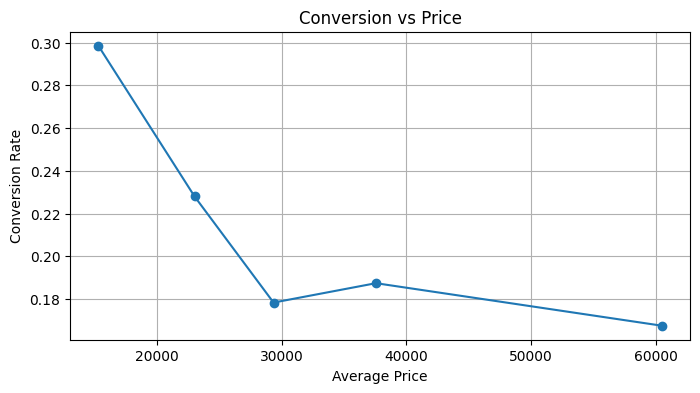

In [22]:
# ------------------------------------------------------------
# STEP 15: PLOT PRICE VS CONVERSION
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(conv_price["avg_price"], conv_price["conversion_rate"], marker='o')

plt.title("Conversion vs Price")
plt.xlabel("Average Price")
plt.ylabel("Conversion Rate")

plt.grid(True)
plt.show()

In [24]:
# ------------------------------------------------------------
# STEP 16: FILTER TO TOP CORRIDORS
# ------------------------------------------------------------

top_corridors = conv_corridor.sort_values(
    "quotes", ascending=False
).head(10)["corridor"]

df_top = df[df["corridor"].isin(top_corridors)].copy()

In [25]:
# ------------------------------------------------------------
# STEP 17: RE-BUCKET PRICE (LOCAL)
# ------------------------------------------------------------

df_top["price_bucket"] = pd.qcut(
    df_top["Quote_Total_Cost"],
    q=5,
    duplicates="drop"
)

In [26]:
# ------------------------------------------------------------
# STEP 18: LOCAL ELASTICITY VIEW
# ------------------------------------------------------------

conv_price_top = (
    df_top.groupby("price_bucket")
    .agg(
        quotes=("Quote_ID", "count"),
        conversion_rate=("converted", "mean"),
        avg_price=("Quote_Total_Cost", "mean")
    )
    .reset_index()
    .sort_values("avg_price")
)

conv_price_top

/var/tmp/ipykernel_20452/3257836934.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_top.groupby("price_bucket")


,price_bucket,quotes,conversion_rate,avg_price
0,"(8849.999, 17399.95]",697,0.307030,13733.894333
1,"(17399.95, 23962.878]",685,0.258394,20412.237299
2,"(23962.878, 30152.512]",690,0.186957,27233.400507
3,"(30152.512, 39368.22]",691,0.224313,33956.718654
4,"(39368.22, 95784.32]",691,0.222865,56866.325007


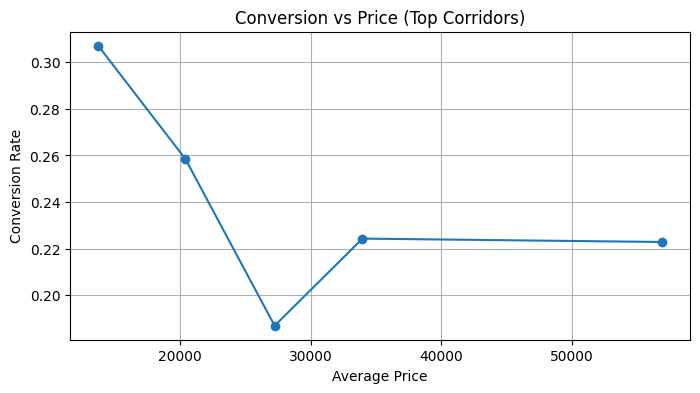

In [27]:
# ------------------------------------------------------------
# STEP 19: VISUALIZE CLEANER CURVE
# ------------------------------------------------------------

plt.figure(figsize=(8,4))

plt.plot(conv_price_top["avg_price"], conv_price_top["conversion_rate"], marker='o')

plt.title("Conversion vs Price (Top Corridors)")
plt.xlabel("Average Price")
plt.ylabel("Conversion Rate")

plt.grid(True)
plt.show()

In [30]:
# ------------------------------------------------------------
# STEP 1: CHECK AVAILABLE COLUMNS
# ------------------------------------------------------------

print(df.columns)

Index(['Quote_ID', 'Date_Quoted', 'Trip_Departure_Date', 'dep_icao',
       'arr_icao', 'dep_cluster', 'arr_cluster', 'corridor',
       'Quote_Total_Cost', 'Trip_Status', 'converted', 'booked_flag',
       'price_bucket'],
      dtype='object')


In [31]:
# ------------------------------------------------------------
# STEP 1: CONVERT TO DATETIME
# ------------------------------------------------------------

df["Date_Quoted"] = pd.to_datetime(df["Date_Quoted"], errors="coerce")
df["Trip_Departure_Date"] = pd.to_datetime(df["Trip_Departure_Date"], errors="coerce")

# ------------------------------------------------------------
# STEP 2: CREATE DFD
# ------------------------------------------------------------

df["DFD"] = (df["Trip_Departure_Date"] - df["Date_Quoted"]).dt.days

# ------------------------------------------------------------
# STEP 3: CLEAN INVALID VALUES
# ------------------------------------------------------------

# remove nulls and negative values
df = df[df["DFD"].notna()].copy()
df = df[df["DFD"] >= 0].copy()

print(df["DFD"].describe())

count    17076.000000
mean        14.974350
std         14.427261
min          0.000000
25%          4.000000
50%          9.000000
75%         22.000000
max         60.000000
Name: DFD, dtype: float64


In [32]:
# ------------------------------------------------------------
# STEP 4: BUCKET DFD
# ------------------------------------------------------------

def dfd_bucket(x):
    if x <= 2:
        return "0-2"
    elif x <= 6:
        return "3-6"
    elif x <= 13:
        return "7-13"
    else:
        return "14+"

df["dfd_bucket"] = df["DFD"].apply(dfd_bucket)

print(df["dfd_bucket"].value_counts())

dfd_bucket
14+     6787
3-6     3957
7-13    3694
0-2     2638
Name: count, dtype: int64


In [33]:
df[["Date_Quoted", "Trip_Departure_Date", "DFD"]].head(10)

,Date_Quoted,Trip_Departure_Date,DFD
0,2015-12-31,2016-01-04,4
2,2015-12-31,2016-01-02,2
3,2015-12-31,2016-01-08,8
4,2015-12-31,2016-01-02,2
6,2015-12-31,2016-01-08,8
7,2015-12-31,2016-01-03,3
9,2015-12-31,2016-01-05,5
10,2015-12-30,2016-02-05,37
11,2015-12-31,2016-01-06,6
12,2015-12-31,2016-01-06,6


In [36]:
# ------------------------------------------------------------
# STEP: CONVERSION BY PRICE BUCKET AND DFD
# ------------------------------------------------------------

conv_price_dfd = (
    df.groupby(["price_bucket", "dfd_bucket"])
    .agg(
        conversion_rate=("booked_flag", "mean"),
        avg_price=("Quote_Total_Cost", "mean"),
        count=("Quote_Total_Cost", "count")
    )
    .reset_index()
)

# remove low-sample noise
conv_price_dfd = conv_price_dfd[conv_price_dfd["count"] > 30]

conv_price_dfd.sort_values(["price_bucket", "dfd_bucket"]).head(20)

/var/tmp/ipykernel_20452/3758962054.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["price_bucket", "dfd_bucket"])


,price_bucket,dfd_bucket,conversion_rate,avg_price,count
0,"(8799.999, 19500.0]",0-2,0.321168,14903.355961,822
1,"(8799.999, 19500.0]",14+,0.271903,15888.464632,993
2,"(8799.999, 19500.0]",3-6,0.321739,15026.420185,920
3,"(8799.999, 19500.0]",7-13,0.343023,15257.583270,688
4,"(19500.0, 26202.13]",0-2,0.248428,22782.526619,636
5,"(19500.0, 26202.13]",14+,0.236189,23077.020544,1249
6,"(19500.0, 26202.13]",3-6,0.246626,23006.250503,815
7,"(19500.0, 26202.13]",7-13,0.262712,23124.139308,708
8,"(26202.13, 32513.38]",0-2,0.217105,29367.959605,456
9,"(26202.13, 32513.38]",14+,0.180267,29396.294325,1348


In [37]:
# ------------------------------------------------------------
# STEP: PIVOT TABLE (EASIER TO READ)
# ------------------------------------------------------------

pivot_dfd = conv_price_dfd.pivot(
    index="price_bucket",
    columns="dfd_bucket",
    values="conversion_rate"
)

pivot_dfd


dfd_bucket,0-2,14+,3-6,7-13
price_bucket,,,,
"(8799.999, 19500.0]",0.321168,0.271903,0.321739,0.343023
"(19500.0, 26202.13]",0.248428,0.236189,0.246626,0.262712
"(26202.13, 32513.38]",0.217105,0.180267,0.214976,0.177522
"(32513.38, 45337.82]",0.206019,0.214286,0.193464,0.188144
"(45337.82, 99195.0]",0.188356,0.164103,0.217806,0.202977


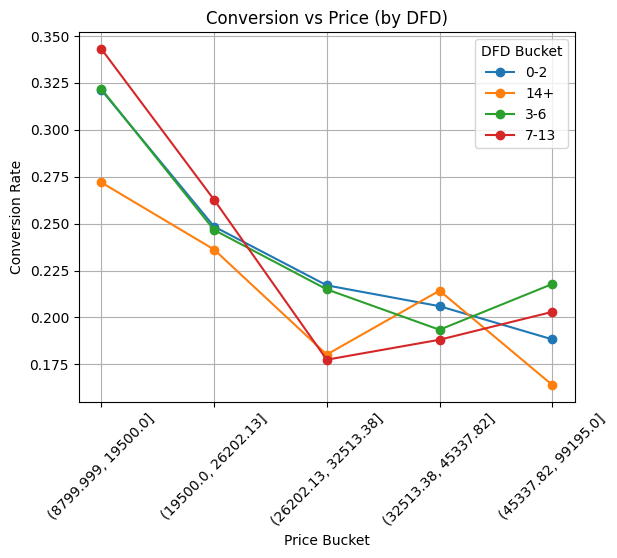

In [38]:
# ------------------------------------------------------------
# STEP: VISUALIZE CURVES
# ------------------------------------------------------------

import matplotlib.pyplot as plt

for dfd in pivot_dfd.columns:
    plt.plot(pivot_dfd.index.astype(str), pivot_dfd[dfd], marker="o", label=dfd)

plt.title("Conversion vs Price (by DFD)")
plt.xlabel("Price Bucket")
plt.ylabel("Conversion Rate")
plt.legend(title="DFD Bucket")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [43]:
# normalize once

df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['quote_id', 'date_quoted', 'trip_departure_date', 'dep_icao',
       'arr_icao', 'dep_cluster', 'arr_cluster', 'corridor',
       'quote_total_cost', 'trip_status', 'converted', 'booked_flag',
       'price_bucket', 'dfd', 'dfd_bucket'],
      dtype='object')


In [44]:
pivot_price_dfd = conv_price_dfd.pivot(
    index="price_bucket",
    columns="dfd_bucket",
    values="conversion_rate"
)

pivot_price_dfd

dfd_bucket,0-2,14+,3-6,7-13
price_bucket,,,,
"(8799.999, 19500.0]",0.321168,0.271903,0.321739,0.343023
"(19500.0, 26202.13]",0.248428,0.236189,0.246626,0.262712
"(26202.13, 32513.38]",0.217105,0.180267,0.214976,0.177522
"(32513.38, 45337.82]",0.206019,0.214286,0.193464,0.188144
"(45337.82, 99195.0]",0.188356,0.164103,0.217806,0.202977


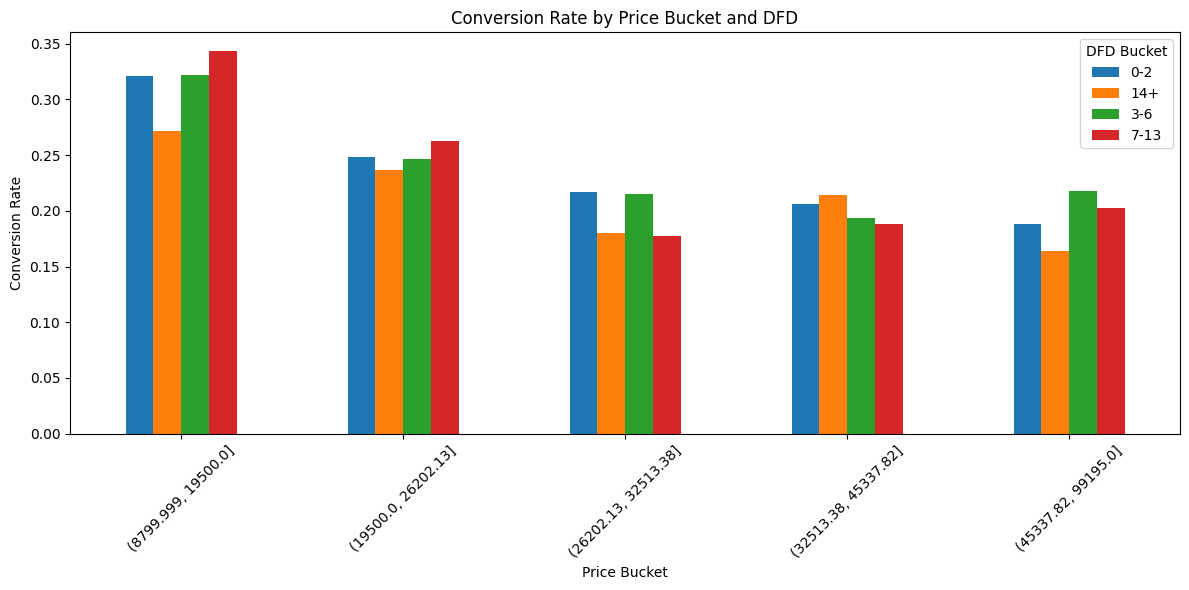

In [45]:
import matplotlib.pyplot as plt

pivot_price_dfd.plot(kind="bar", figsize=(12,6))

plt.title("Conversion Rate by Price Bucket and DFD")
plt.ylabel("Conversion Rate")
plt.xlabel("Price Bucket")
plt.xticks(rotation=45)
plt.legend(title="DFD Bucket")

plt.tight_layout()
plt.show()

In [46]:
#CELL 27: ADD CORRIDOR LAYER (HIGH SIGNAL)
conv_corridor_price_dfd = (
    df.groupby(["corridor", "price_bucket", "dfd_bucket"])
    .agg(
        conversion_rate=("booked_flag", "mean"),
        count=("quote_total_cost", "count")
    )
    .reset_index()
)

# keep only meaningful corridors
conv_corridor_price_dfd = conv_corridor_price_dfd[
    conv_corridor_price_dfd["count"] > 30
]

conv_corridor_price_dfd.head()

/var/tmp/ipykernel_20452/3356059115.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["corridor", "price_bucket", "dfd_bucket"])


,corridor,price_bucket,dfd_bucket,conversion_rate,count
5009,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,"(26202.13, 32513.38]",14+,0.163265,49
5010,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,"(26202.13, 32513.38]",3-6,0.320755,53
5011,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,"(26202.13, 32513.38]",7-13,0.134615,52
5013,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,"(32513.38, 45337.82]",14+,0.181818,33
5017,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,"(45337.82, 99195.0]",14+,0.166667,36


In [50]:
# conversion spread across price buckets per corridor + dfd
#CELL 28: FIND WHERE PRICE DOES NOT MATTER (GOLD)


spread = (
    conv_corridor_price_dfd
    .groupby(["corridor", "dfd_bucket"])
    .agg(
        max_conv=("conversion_rate", "max"),
        min_conv=("conversion_rate", "min")
    )
    .reset_index()
)

spread["spread"] = spread["max_conv"] - spread["min_conv"]

# low spread = price doesn't matter
price_insensitive = spread.sort_values("spread").head(20)

price_insensitive

,corridor,dfd_bucket,max_conv,min_conv,spread
1,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,3-6,0.320755,0.320755,0.000000
3,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,0-2,0.255814,0.255814,0.000000
5,LOS_ANGELES_CLUSTER→WASHINGTON_DC_CLUSTER,14+,0.181818,0.181818,0.000000
4,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,3-6,0.290323,0.290323,0.000000
6,MIAMI_CLUSTER→BOSTON_CLUSTER,14+,0.396226,0.396226,0.000000
15,NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,3-6,0.200000,0.200000,0.000000
10,MIAMI_CLUSTER→NEW_YORK_CLUSTER,7-13,0.474576,0.474576,0.000000
11,NEW_YORK_CLUSTER→BOSTON_CLUSTER,14+,0.272727,0.272727,0.000000
13,NEW_YORK_CLUSTER→LAS_VEGAS_CLUSTER,14+,0.125000,0.125000,0.000000
25,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,3-6,0.156250,0.156250,0.000000


In [48]:
#CELL 29: FIND URGENCY-DRIVEN CONVERSION
urgency_effect = (
    conv_corridor_price_dfd
    .groupby(["corridor", "price_bucket"])
    .agg(
        max_conv=("conversion_rate", "max"),
        min_conv=("conversion_rate", "min")
    )
    .reset_index()
)

urgency_effect["dfd_spread"] = urgency_effect["max_conv"] - urgency_effect["min_conv"]

# high spread = urgency matters
urgency_sensitive = urgency_effect.sort_values("dfd_spread", ascending=False).head(20)

urgency_sensitive

/var/tmp/ipykernel_20452/1932373120.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["corridor", "price_bucket"])


,corridor,price_bucket,max_conv,min_conv,dfd_spread
65,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,"(8799.999, 19500.0]",0.431818,0.156250,0.275568
20,MIAMI_CLUSTER→NEW_YORK_CLUSTER,"(8799.999, 19500.0]",0.474576,0.283333,0.191243
2,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,"(26202.13, 32513.38]",0.320755,0.134615,0.186139
45,NEW_YORK_CLUSTER→MIAMI_CLUSTER,"(8799.999, 19500.0]",0.361111,0.177778,0.183333
46,NEW_YORK_CLUSTER→MIAMI_CLUSTER,"(19500.0, 26202.13]",0.311111,0.230769,0.080342
48,NEW_YORK_CLUSTER→MIAMI_CLUSTER,"(32513.38, 45337.82]",0.275362,0.204545,0.070817
21,MIAMI_CLUSTER→NEW_YORK_CLUSTER,"(19500.0, 26202.13]",0.281250,0.212121,0.069129
74,SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER,"(45337.82, 99195.0]",0.315789,0.277778,0.038012
5,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,"(8799.999, 19500.0]",0.290323,0.255814,0.034509
42,NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,"(26202.13, 32513.38]",0.200000,0.173913,0.026087


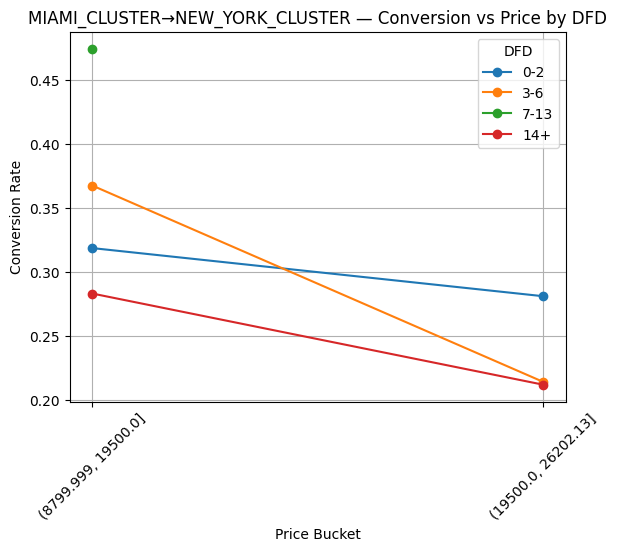

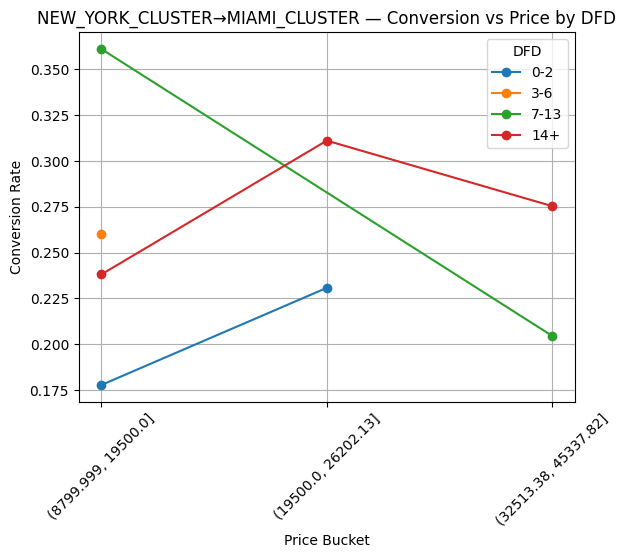

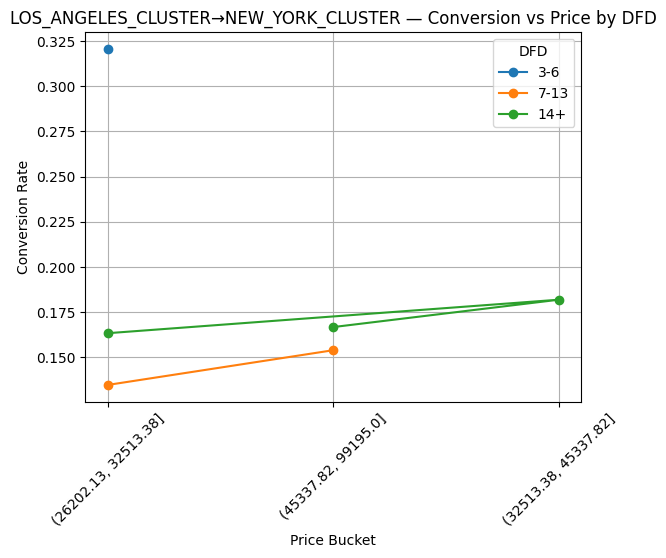

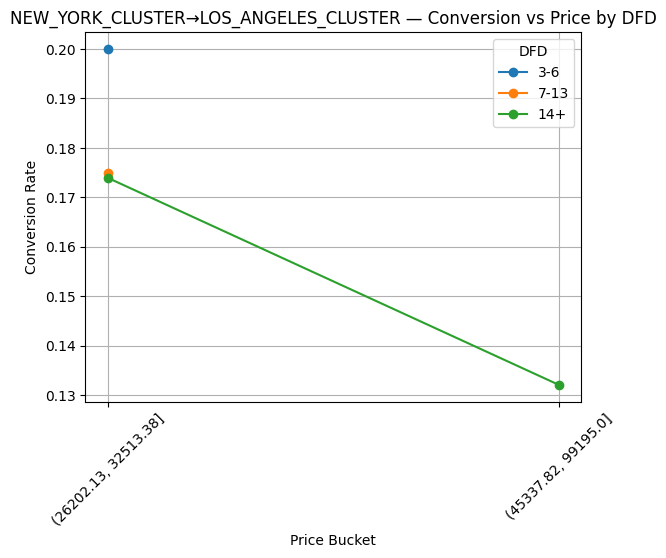

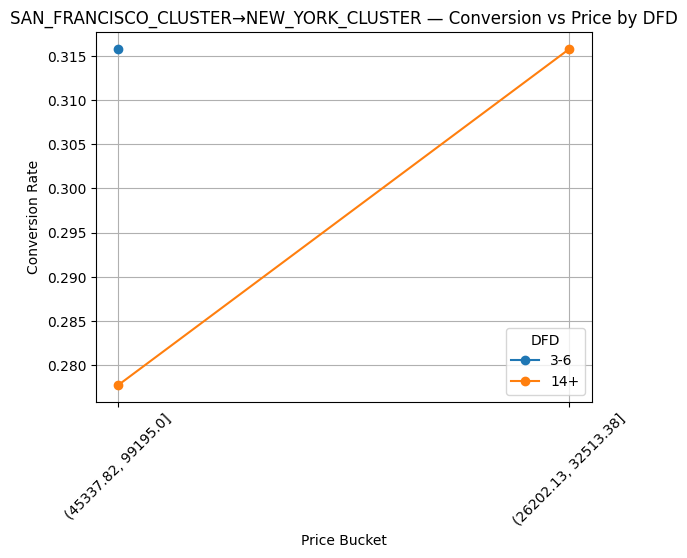

In [53]:
for corridor in top_corridors[:5]:
    subset = conv_corridor_price_dfd[
        conv_corridor_price_dfd["corridor"] == corridor
    ]

    plt.figure()

    for dfd in ["0-2", "3-6", "7-13", "14+"]:
        d = subset[subset["dfd_bucket"] == dfd]
        if len(d) > 0:
            plt.plot(
                d["price_bucket"].astype(str),
                d["conversion_rate"],
                marker="o",
                label=dfd
            )

    plt.title(f"{corridor} — Conversion vs Price by DFD")
    plt.xlabel("Price Bucket")
    plt.ylabel("Conversion Rate")
    plt.legend(title="DFD")
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.show()